## Quantum Teleportation

#### Quantum teleportation means to transfer an unknown quantum state,using a pair of entangled particles,from Alice to Bob with a classical channel.In this notebook we will see how it works:

#### First we need to import required libraries!

In [1]:
import numpy as np
from qiskit import *
from qiskit.quantum_info import *

In [2]:
def qplot(x):
    return x.draw(fold=False,initial_state=True,scale=0.8)

#### Step by Step

### 1.Initialization:
We have q0 which is in an unknown state $|\psi\rangle=\alpha|0\rangle + \beta|1\rangle$.
We want to teleport this unknown state to Bob!

In [3]:
qc=QuantumCircuit(3,2)
qc.ry(1.2,0)
qc.draw("mpl")
display(qplot(qc),Statevector(qc).draw('latex'))

┌─────────┐
q_0: |0>┤ Ry(1.2) ├
        └─────────┘
q_1: |0>───────────
                   
q_2: |0>───────────
                   
 c: 0 2/═══════════

<IPython.core.display.Latex object>

### 2.Creating entangled pairs using Hadamard and CNOT gate!

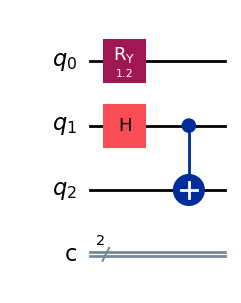

In [4]:
qc.h(1)
qc.cx(1,2)

qc.draw("mpl")


### 3.Alice Bell Measurement

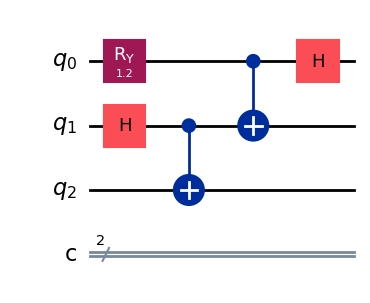

In [5]:
qc.cx(0,1)
qc.h(0)

qc.draw("mpl")


### 4.Alice's Measurement

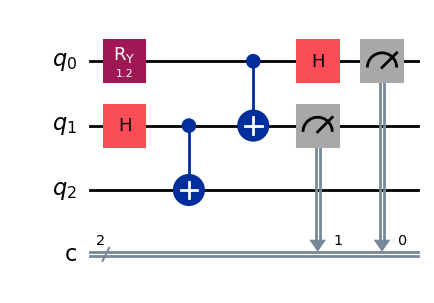

In [6]:
qc.measure(0,0)
qc.measure(1,1)

qc.draw("mpl")


### 5.Bob's operation

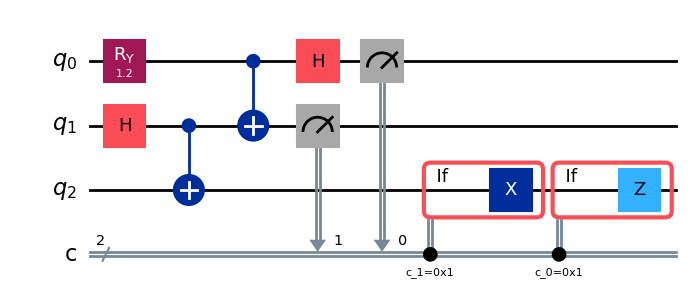

In [7]:
with qc.if_test((qc.clbits[1], 1)):
    qc.x(2)

with qc.if_test((qc.clbits[0], 1)):
    qc.z(2)

display(qc.draw("mpl"))

### How do we know that the unknown state has been successfully teleported?

After Alice's measurement, the statevector of the **whole 3-qubit system** is no longer a good way to display Bob's state directly: measurement collapses the state and the result is stored in classical bits.

Also, before Bob's corrections, Bob does **not** necessarily have $|\psi\rangle$; depending on Alice's two classical bits, Bob has one of
$|\psi\rangle$, $X|\psi\rangle$, $Z|\psi\rangle$, or $XZ|\psi\rangle$.

For a clean verification, we therefore repeat the circuit **without measurement**, apply Bob's corrections coherently using the two Alice qubits as controls, and then extract Bob's reduced state.

If teleportation works, Bob's final state must be exactly the original unknown state $|\psi\rangle$.

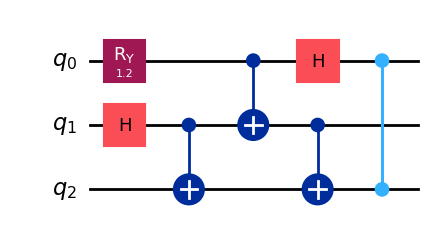

Full 3-qubit state after Bob's corrections:


<IPython.core.display.Latex object>

Bob's reduced density matrix:


<IPython.core.display.Latex object>

Original unknown state |ψ>:


<IPython.core.display.Latex object>

Bob's state is equal to the original state: True


In [9]:
# Verification circuit: no measurement
# This lets us inspect the quantum state before it is destroyed by measurement.

qc_check = QuantumCircuit(3)

# 1. Unknown state |psi> on Alice's qubit
qc_check.ry(1.2, 0)

# 2. Create the entangled pair
qc_check.h(1)
qc_check.cx(1, 2)

# 3. Alice's Bell-basis operations
qc_check.cx(0, 1)
qc_check.h(0)

# 4. Bob's corrections, implemented coherently
#    q1 = 1  -> X on Bob
#    q0 = 1  -> Z on Bob
qc_check.cx(1, 2)
qc_check.cz(0, 2)

display(qc_check.draw("mpl"))

# Full 3-qubit state after teleportation + correction
sv_final = Statevector.from_instruction(qc_check)

print("Full 3-qubit state after Bob's corrections:")
display(sv_final.draw("latex"))

# Extract Bob's reduced density matrix
rho_bob = partial_trace(sv_final, [0, 1])

print("Bob's reduced density matrix:")
display(rho_bob.draw("latex"))

# Original unknown state
psi_circuit = QuantumCircuit(1)
psi_circuit.ry(1.2, 0)

psi = Statevector.from_instruction(psi_circuit)

print("Original unknown state |ψ>:")
display(psi.draw("latex"))

print("Bob's state is equal to the original state:",
      np.allclose(rho_bob.data, np.outer(psi.data, psi.data.conj())))


### What happens in the actual measurement?

In the real protocol, Alice obtains one of four classical results:
$00$, $01$, $10$, or $11$.

The corresponding correction on Bob is:

| Alice's result | Bob's state before correction | Bob's correction |
|---|---|---|
| $00$ | $|\psi\rangle$ | $I$ |
| $01$ | $X|\psi\rangle$ | $X$ |
| $10$ | $Z|\psi\rangle$ | $Z$ |
| $11$ | $XZ|\psi\rangle$ | $X$ then $Z$ |

So we should **not** expect the measured 3-qubit statevector to simply print $|\psi\rangle$.

The deterministic verification above avoids this problem and proves that, after receiving Alice's two classical bits and applying the corresponding corrections, Bob has the original state.